# **1° — Imports**

Bibliotecas utilizadas para manipulação dos dados, visualização, padronização, clusterização, validação cruzada, regressão e avaliação dos modelos.

Nesta versão foram removidos imports de classificadores que não eram utilizados, mantendo somente os componentes necessários para o problema de **regressão**.

In [1]:
from pathlib import Path
from time import perf_counter
import os

# Limita o paralelismo interno para evitar travamentos em kernels compartilhados.
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display

from sklearn.base import clone
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score,
)
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

SEMENTE = 42
np.random.seed(SEMENTE)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda valor: f"{valor:,.4f}")

# **2° — Verificar se a importação do dataset ocorreu corretamente**

1. O `read_csv` carrega o arquivo `crop_yield.csv` na variável `dados`.
2. O código procura o arquivo tanto no caminho padrão do Google Colab quanto no diretório do notebook.
3. São verificados formato, colunas, valores ausentes, duplicidades, tipos e estatísticas descritivas.
4. As primeiras cinco observações são exibidas para uma inspeção inicial.

In [2]:
caminhos_candidatos = [
    Path("/content/crop_yield.csv"),
    Path.cwd() / "crop_yield.csv",
    Path.cwd() / "data" / "crop_yield.csv",
]

caminho_dataset = next(
    (caminho for caminho in caminhos_candidatos if caminho.exists()),
    None,
)

if caminho_dataset is None:
    caminhos_testados = "\n".join(f"- {caminho}" for caminho in caminhos_candidatos)
    raise FileNotFoundError(
        "O arquivo 'crop_yield.csv' não foi encontrado. "
        "Faça o upload do CSV no Colab ou coloque-o ao lado do notebook.\n"
        f"Caminhos testados:\n{caminhos_testados}"
    )

dados = pd.read_csv(caminho_dataset)

colunas_esperadas = [
    "Crop",
    "Precipitation (mm day-1)",
    "Specific Humidity at 2 Meters (g/kg)",
    "Relative Humidity at 2 Meters (%)",
    "Temperature at 2 Meters (C)",
    "Yield",
]

colunas_ausentes = sorted(set(colunas_esperadas) - set(dados.columns))
if colunas_ausentes:
    raise ValueError(f"Colunas obrigatórias ausentes: {colunas_ausentes}")

dados = dados[colunas_esperadas].copy()

print(f"Arquivo carregado: {caminho_dataset.name}")
print(f"Dimensão: {dados.shape[0]} linhas × {dados.shape[1]} colunas")
print(f"Valores ausentes: {int(dados.isna().sum().sum())}")
print(f"Linhas duplicadas: {int(dados.duplicated().sum())}")
print("\nInformações da base:")
dados.info()

print("\nPrimeiras cinco observações:")
display(dados.head())

print("Estatísticas descritivas das variáveis numéricas:")
display(dados.describe().T)

print("Quantidade de registros por cultura:")
display(dados["Crop"].value_counts().rename_axis("Cultura").to_frame("Registros"))

Arquivo carregado: crop_yield.csv
Dimensão: 156 linhas × 6 colunas
Valores ausentes: 0
Linhas duplicadas: 0

Informações da base:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    object 
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.4+ KB

Primeiras cinco observações:


,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans","2,248.9200",17.7200,83.4000,26.0100,11560
1,"Cocoa, beans","1,938.4200",17.5400,82.1100,26.1100,11253
2,"Cocoa, beans","2,301.5400",17.8100,82.7900,26.2400,9456
3,"Cocoa, beans","2,592.3500",17.6100,85.0700,25.5600,9321
4,"Cocoa, beans","2,344.7200",17.6100,84.1200,25.7600,8800


Estatísticas descritivas das variáveis numéricas:


,count,mean,std,min,25%,50%,75%,max
Precipitation (mm day-1),156.0000,"2,486.4990",289.4579,"1,934.6200","2,302.9900","2,424.5500","2,718.0800","3,085.7900"
Specific Humidity at 2 Meters (g/kg),156.0000,18.2031,0.2939,17.5400,18.0300,18.2700,18.4000,18.7000
Relative Humidity at 2 Meters (%),156.0000,84.7377,0.9962,82.1100,84.1200,84.8500,85.5100,86.1000
Temperature at 2 Meters (C),156.0000,26.1836,0.2610,25.5600,26.0200,26.1300,26.3000,26.8100
Yield,156.0000,"56,153.0962","70,421.9589","5,249.0000","8,327.7500","18,871.0000","67,518.7500","203,399.0000"


Quantidade de registros por cultura:


,Registros
Cultura,
"Cocoa, beans",39
Oil palm fruit,39
"Rice, paddy",39
"Rubber, natural",39


# **3° — Visualizar média e distribuição das variáveis**

Os histogramas permitem observar a frequência de cada faixa de valores. Para as variáveis numéricas, a linha tracejada representa a média. Para `Crop`, é apresentada a frequência de cada cultura.

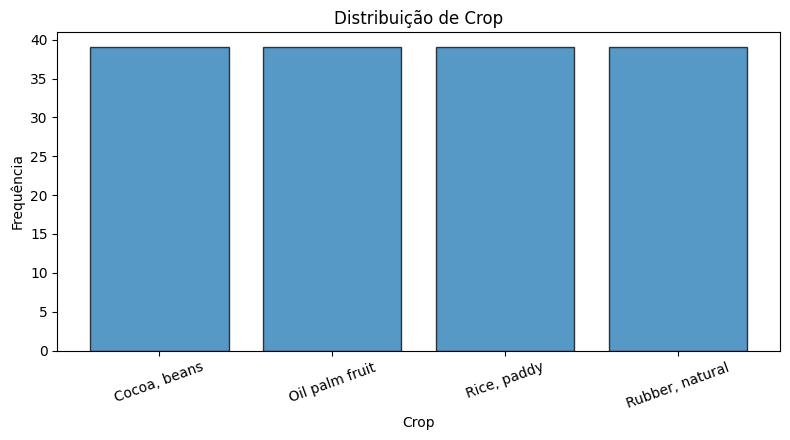

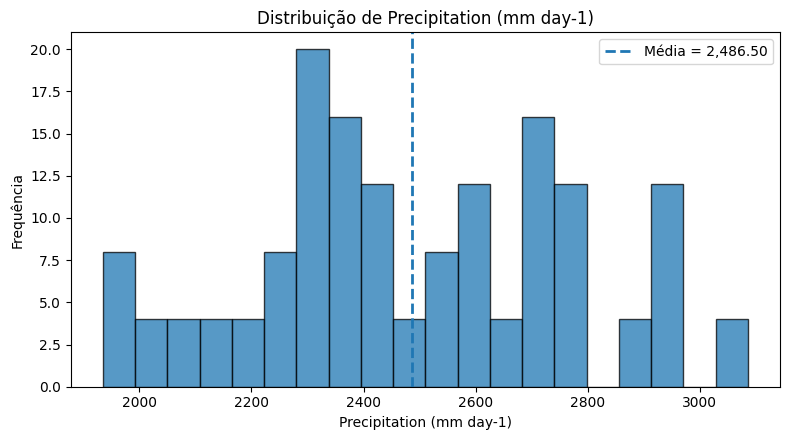

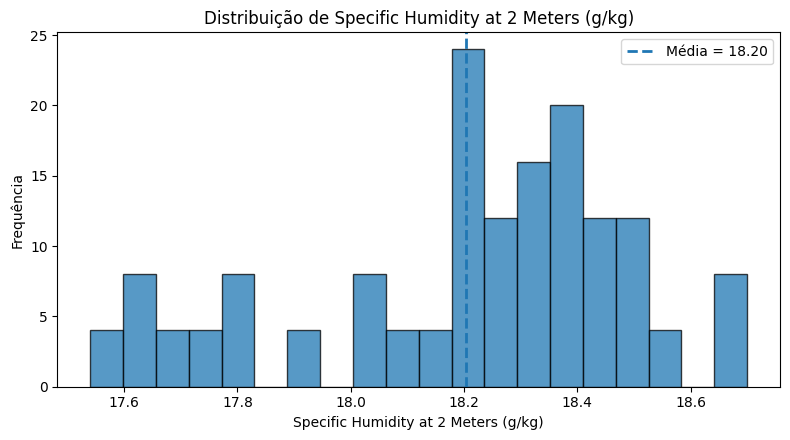

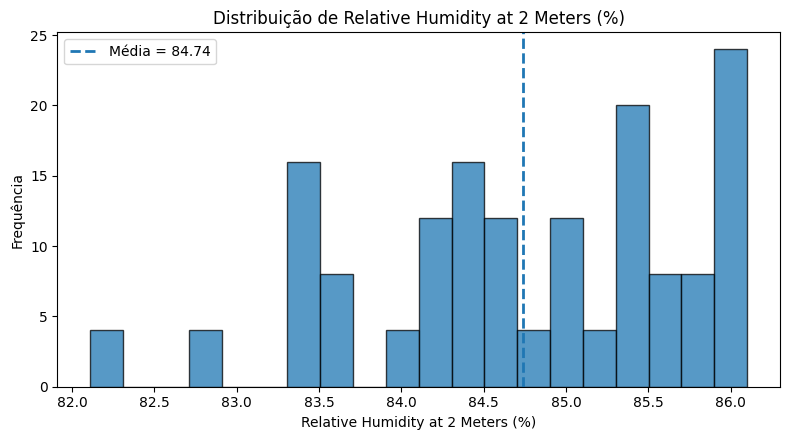

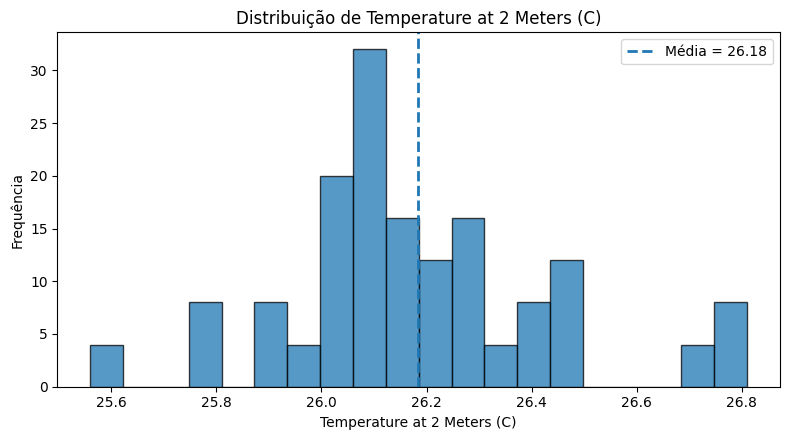

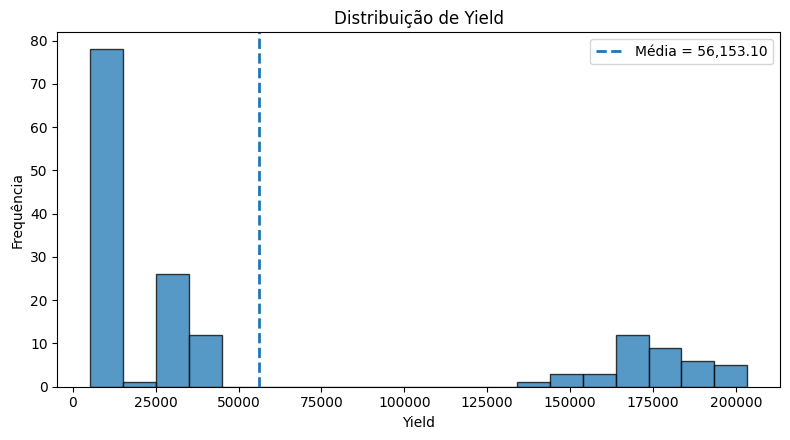

In [3]:
for coluna in dados.columns:
    fig, eixo = plt.subplots(figsize=(8, 4.5))

    if pd.api.types.is_numeric_dtype(dados[coluna]):
        eixo.hist(dados[coluna], bins=20, edgecolor="black", alpha=0.75)
        media = dados[coluna].mean()
        eixo.axvline(
            media,
            linestyle="--",
            linewidth=2,
            label=f"Média = {media:,.2f}",
        )
        eixo.legend()
    else:
        frequencias = dados[coluna].value_counts()
        eixo.bar(frequencias.index, frequencias.values, edgecolor="black", alpha=0.75)
        eixo.tick_params(axis="x", rotation=20)

    eixo.set_title(f"Distribuição de {coluna}")
    eixo.set_xlabel(coluna)
    eixo.set_ylabel("Frequência")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

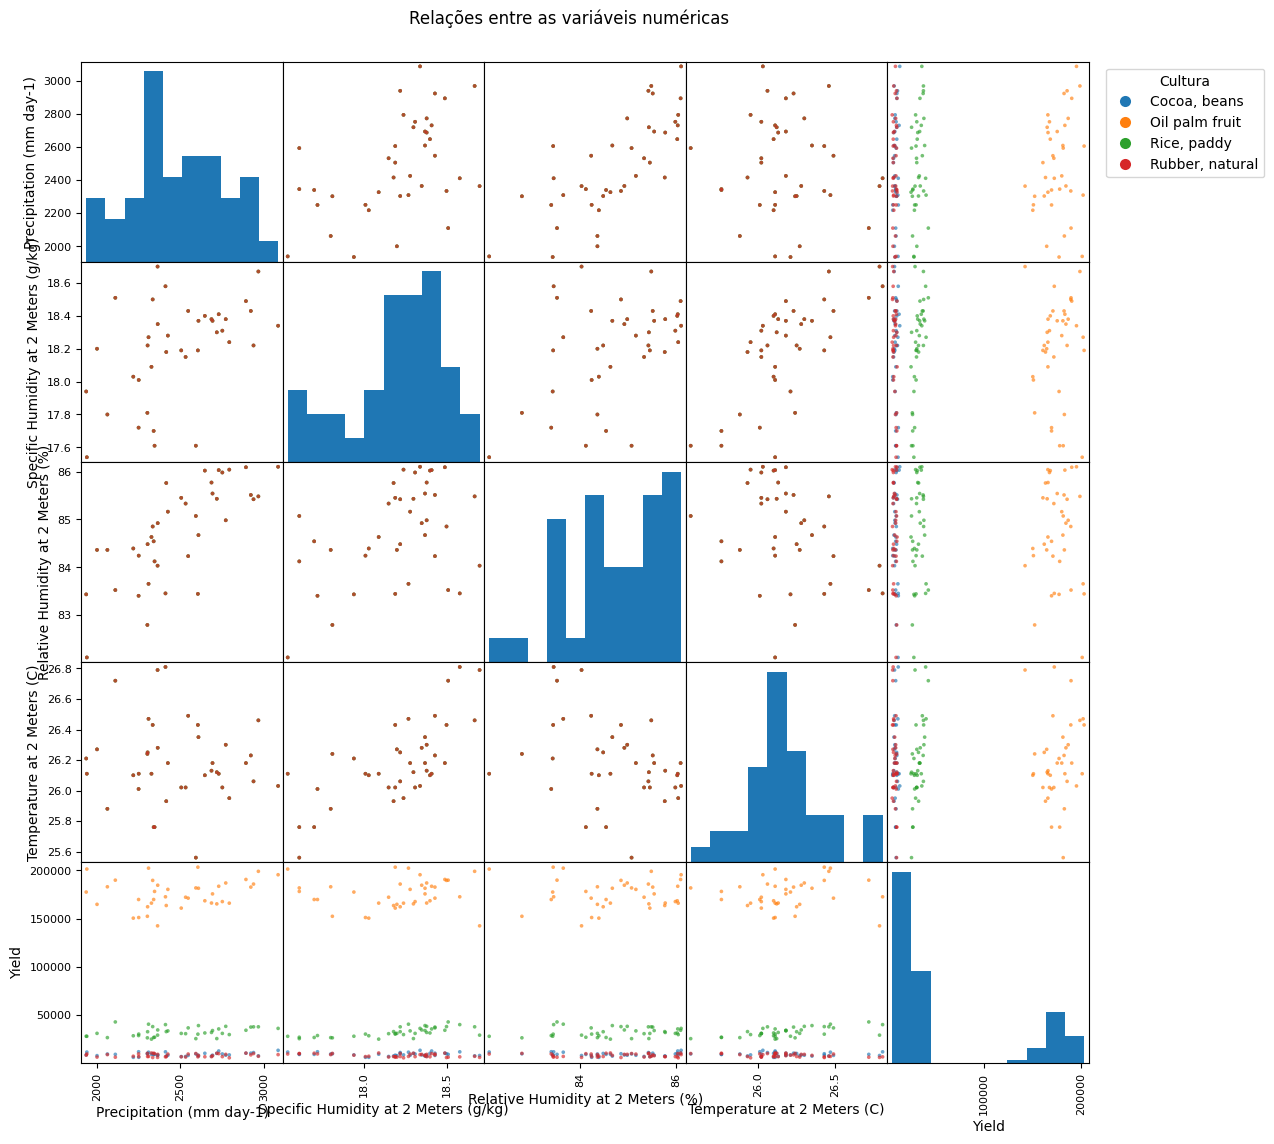

In [4]:
# Matriz de dispersão das variáveis numéricas, com cores representando as culturas.
colunas_numericas = dados.select_dtypes(include=np.number).columns.tolist()
categorias_cultura = pd.Categorical(dados["Crop"])
mapa_cores = plt.colormaps["tab10"]
cores = [mapa_cores(codigo) for codigo in categorias_cultura.codes]

axes = pd.plotting.scatter_matrix(
    dados[colunas_numericas],
    figsize=(13, 13),
    diagonal="hist",
    alpha=0.65,
    c=cores,
    s=28,
)

legenda = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markerfacecolor=mapa_cores(indice),
        markeredgecolor="none",
        label=cultura,
        markersize=8,
    )
    for indice, cultura in enumerate(categorias_cultura.categories)
]

axes[0, -1].legend(
    handles=legenda,
    title="Cultura",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)
plt.suptitle("Relações entre as variáveis numéricas", y=0.92)
plt.show()
plt.close("all")

# **4° — Visualizar a existência de outliers**

O método do intervalo interquartil considera como potenciais outliers os valores menores que `Q1 - 1,5 × IQR` ou maiores que `Q3 + 1,5 × IQR`.

Um valor estatisticamente discrepante não deve ser removido automaticamente. Em `Yield`, por exemplo, parte da diferença pode resultar do fato de as culturas possuírem escalas de rendimento muito distintas.

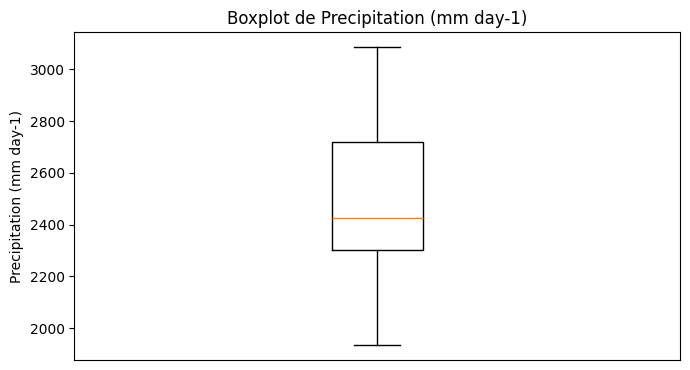

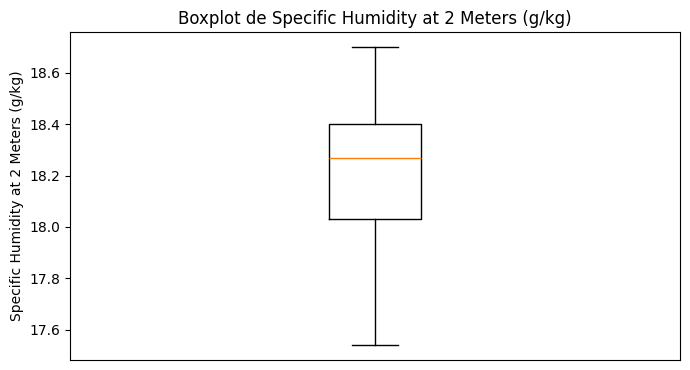

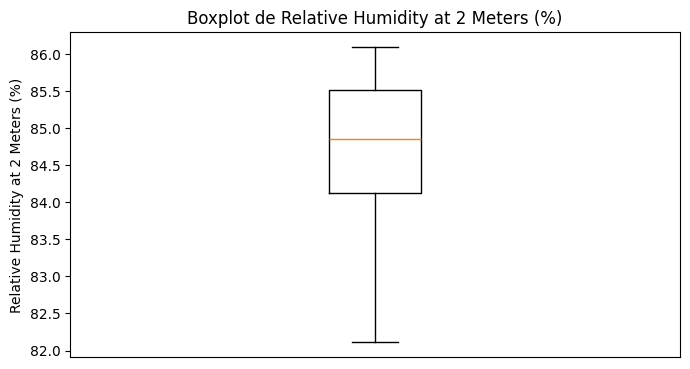

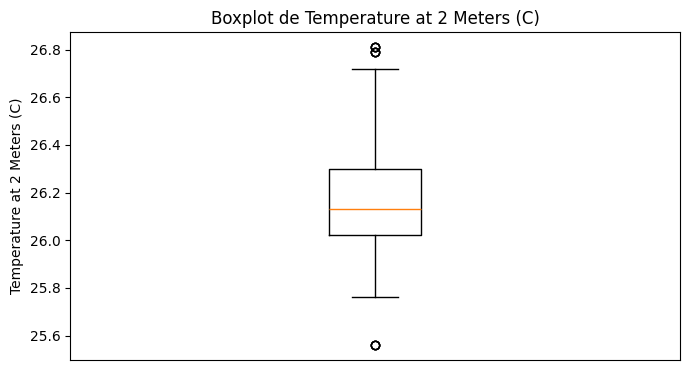

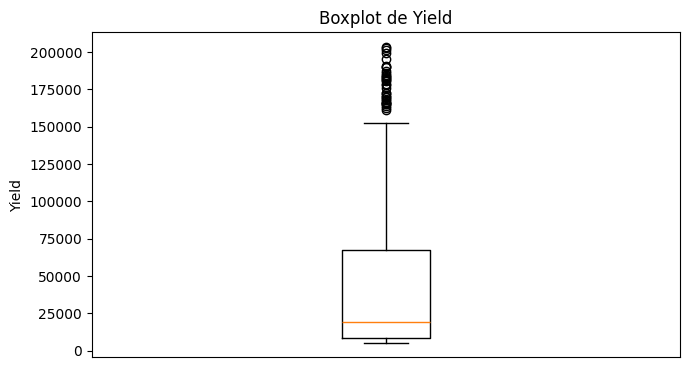

,Variável,Limite inferior,Limite superior,Outliers IQR,Percentual
0,Precipitation (mm day-1),"1,680.3550","3,340.7150",0,0.0000
1,Specific Humidity at 2 Meters (g/kg),17.4750,18.9550,0,0.0000
2,Relative Humidity at 2 Meters (%),82.0350,87.5950,0,0.0000
3,Temperature at 2 Meters (C),25.6000,26.7200,12,7.6900
4,Yield,"-80,458.7500","156,305.2500",35,22.4400


In [5]:
dados_numericos = dados.select_dtypes(include=np.number)
resumo_outliers = []

for coluna in dados_numericos.columns:
    q1 = dados_numericos[coluna].quantile(0.25)
    q3 = dados_numericos[coluna].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    mascara_outlier = (
        (dados_numericos[coluna] < limite_inferior)
        | (dados_numericos[coluna] > limite_superior)
    )
    quantidade = int(mascara_outlier.sum())

    resumo_outliers.append(
        {
            "Variável": coluna,
            "Limite inferior": limite_inferior,
            "Limite superior": limite_superior,
            "Outliers IQR": quantidade,
            "Percentual": 100 * quantidade / len(dados),
        }
    )

    fig, eixo = plt.subplots(figsize=(7, 3.8))
    eixo.boxplot(dados_numericos[coluna], vert=True)
    eixo.set_title(f"Boxplot de {coluna}")
    eixo.set_ylabel(coluna)
    eixo.set_xticks([])
    plt.tight_layout()
    plt.show()
    plt.close(fig)

resumo_outliers = pd.DataFrame(resumo_outliers)
resumo_outliers["Limite inferior"] = resumo_outliers["Limite inferior"].round(3)
resumo_outliers["Limite superior"] = resumo_outliers["Limite superior"].round(3)
resumo_outliers["Percentual"] = resumo_outliers["Percentual"].round(2)
display(resumo_outliers)

# **5° — Visualizar a correlação entre as variáveis**

A matriz de correlação de Pearson permite observar associações lineares entre as variáveis numéricas. Correlação não implica causalidade e relações não lineares podem não ser capturadas.

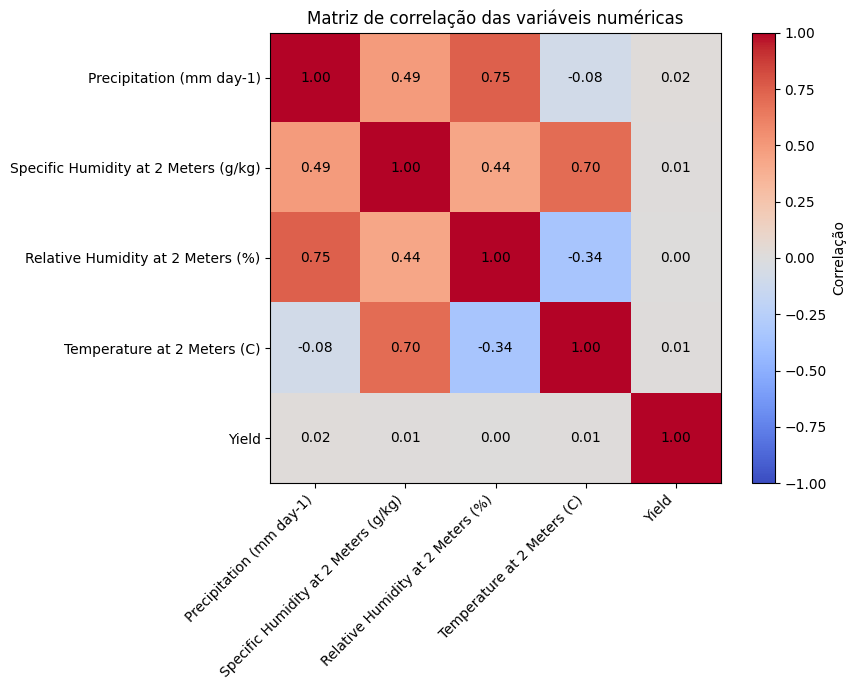

In [6]:
matriz_correlacao = dados_numericos.corr()

fig, eixo = plt.subplots(figsize=(9, 7))
imagem = eixo.imshow(matriz_correlacao, cmap="coolwarm", vmin=-1, vmax=1)

nomes = matriz_correlacao.columns.tolist()
eixo.set_xticks(range(len(nomes)), nomes, rotation=45, ha="right")
eixo.set_yticks(range(len(nomes)), nomes)

for linha in range(len(nomes)):
    for coluna in range(len(nomes)):
        eixo.text(
            coluna,
            linha,
            f"{matriz_correlacao.iloc[linha, coluna]:.2f}",
            ha="center",
            va="center",
        )

fig.colorbar(imagem, ax=eixo, label="Correlação")
eixo.set_title("Matriz de correlação das variáveis numéricas")
plt.tight_layout()
plt.show()
plt.close(fig)

# **6° — Clusterização**

Foram mantidos os três pares de interesse definidos no notebook original:

1. precipitação × umidade específica;
2. precipitação × umidade relativa;
3. umidade específica × temperatura.

Como K-Means e DBSCAN utilizam distâncias, os pares são padronizados com `StandardScaler` antes do agrupamento. Sem essa etapa, a precipitação, por possuir valores numericamente maiores, dominaria o cálculo das distâncias.

## **6.1 — K-Means**

Para cada par, o código calcula a inércia para o método do cotovelo e a silhueta para `k` entre 2 e 5. O número de clusters selecionado é aquele com maior silhueta nesse intervalo. Em seguida, os clusters e os centroides são exibidos para os três pares.

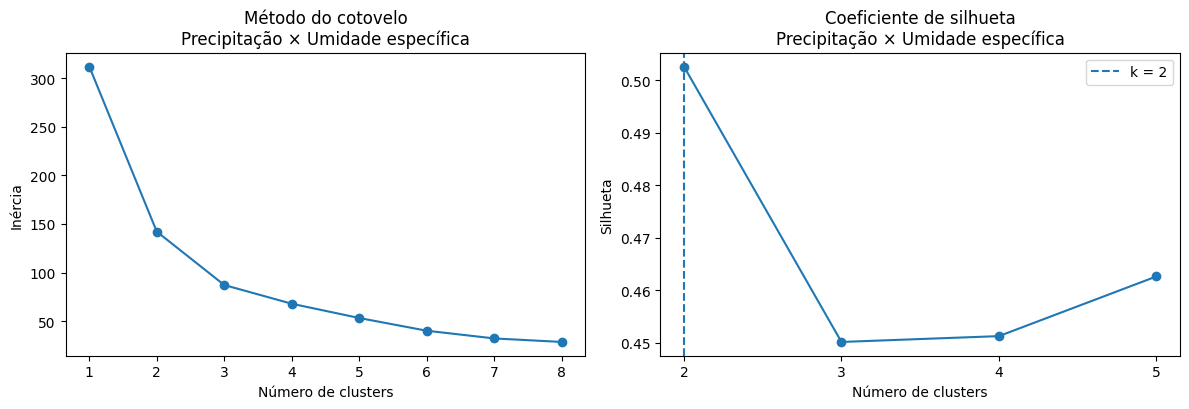

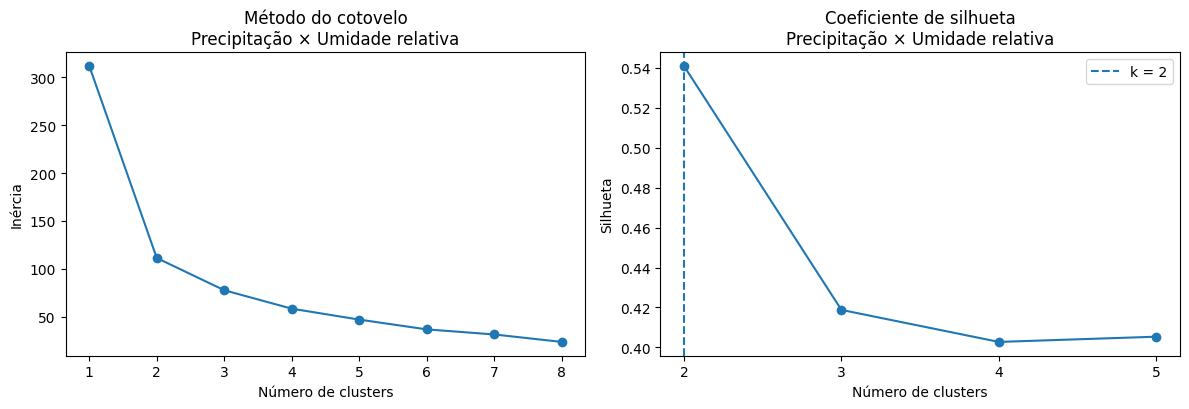

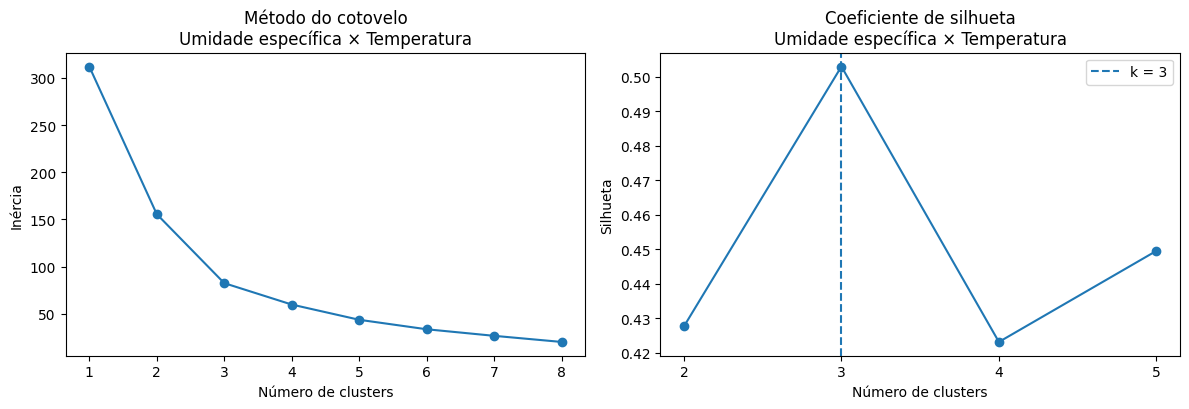

,Par,k selecionado,Silhueta
0,Precipitação × Umidade específica,2,0.5026
1,Precipitação × Umidade relativa,2,0.5410
2,Umidade específica × Temperatura,3,0.5030


In [7]:
COL_PRECIPITACAO = "Precipitation (mm day-1)"
COL_UMIDADE_ESPECIFICA = "Specific Humidity at 2 Meters (g/kg)"
COL_UMIDADE_RELATIVA = "Relative Humidity at 2 Meters (%)"
COL_TEMPERATURA = "Temperature at 2 Meters (C)"

pares_interesse = [
    {
        "nome": "Precipitação × Umidade específica",
        "x": COL_PRECIPITACAO,
        "y": COL_UMIDADE_ESPECIFICA,
    },
    {
        "nome": "Precipitação × Umidade relativa",
        "x": COL_PRECIPITACAO,
        "y": COL_UMIDADE_RELATIVA,
    },
    {
        "nome": "Umidade específica × Temperatura",
        "x": COL_UMIDADE_ESPECIFICA,
        "y": COL_TEMPERATURA,
    },
]

resultados_kmeans = {}
resumo_kmeans = []

for par in pares_interesse:
    matriz_original = dados[[par["x"], par["y"]]].to_numpy()
    padronizador = StandardScaler()
    matriz_padronizada = padronizador.fit_transform(matriz_original)

    valores_k_cotovelo = list(range(1, 9))
    inercias = []
    for k in valores_k_cotovelo:
        modelo = KMeans(n_clusters=k, random_state=SEMENTE, n_init=10)
        modelo.fit(matriz_padronizada)
        inercias.append(modelo.inertia_)

    valores_k_silhueta = list(range(2, 6))
    silhuetas = {}
    for k in valores_k_silhueta:
        modelo = KMeans(n_clusters=k, random_state=SEMENTE, n_init=10)
        rotulos = modelo.fit_predict(matriz_padronizada)
        silhuetas[k] = silhouette_score(matriz_padronizada, rotulos)

    melhor_k = max(silhuetas, key=silhuetas.get)
    modelo_final_kmeans = KMeans(
        n_clusters=melhor_k,
        random_state=SEMENTE,
        n_init=10,
    )
    rotulos_finais = modelo_final_kmeans.fit_predict(matriz_padronizada)
    centroides = padronizador.inverse_transform(modelo_final_kmeans.cluster_centers_)

    resultados_kmeans[par["nome"]] = {
        "par": par,
        "rotulos": rotulos_finais,
        "centroides": centroides,
        "melhor_k": melhor_k,
        "silhueta": silhuetas[melhor_k],
    }

    resumo_kmeans.append(
        {
            "Par": par["nome"],
            "k selecionado": melhor_k,
            "Silhueta": round(silhuetas[melhor_k], 4),
        }
    )

    fig, eixos = plt.subplots(1, 2, figsize=(12, 4.2))
    eixos[0].plot(valores_k_cotovelo, inercias, marker="o")
    eixos[0].set_title(f"Método do cotovelo\n{par['nome']}")
    eixos[0].set_xlabel("Número de clusters")
    eixos[0].set_ylabel("Inércia")
    eixos[0].set_xticks(valores_k_cotovelo)

    eixos[1].plot(
        valores_k_silhueta,
        [silhuetas[k] for k in valores_k_silhueta],
        marker="o",
    )
    eixos[1].axvline(melhor_k, linestyle="--", label=f"k = {melhor_k}")
    eixos[1].set_title(f"Coeficiente de silhueta\n{par['nome']}")
    eixos[1].set_xlabel("Número de clusters")
    eixos[1].set_ylabel("Silhueta")
    eixos[1].set_xticks(valores_k_silhueta)
    eixos[1].legend()

    plt.tight_layout()
    plt.show()
    plt.close(fig)

display(pd.DataFrame(resumo_kmeans))

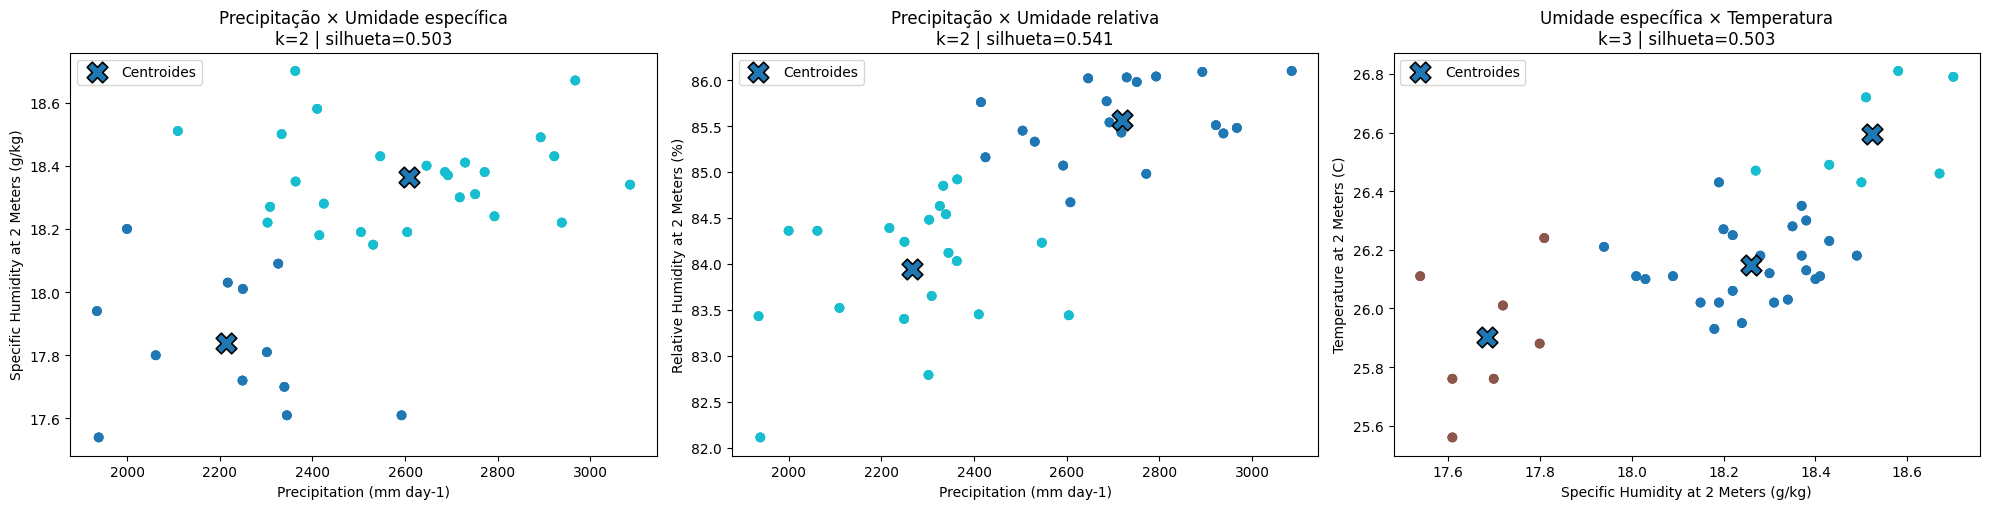

In [8]:
fig, eixos = plt.subplots(1, 3, figsize=(20, 5.2))

for eixo, par in zip(eixos, pares_interesse):
    resultado = resultados_kmeans[par["nome"]]
    eixo.scatter(
        dados[par["x"]],
        dados[par["y"]],
        c=resultado["rotulos"],
        cmap="tab10",
        alpha=0.75,
    )
    eixo.scatter(
        resultado["centroides"][:, 0],
        resultado["centroides"][:, 1],
        marker="X",
        s=220,
        edgecolor="black",
        linewidth=1.2,
        label="Centroides",
    )
    eixo.set_title(
        f"{par['nome']}\n"
        f"k={resultado['melhor_k']} | silhueta={resultado['silhueta']:.3f}"
    )
    eixo.set_xlabel(par["x"])
    eixo.set_ylabel(par["y"])
    eixo.legend()

plt.tight_layout()
plt.show()
plt.close(fig)

## **6.2 — DBSCAN**

O DBSCAN depende principalmente de `eps`, que define o raio máximo da vizinhança, e `min_samples`, que define a quantidade mínima de pontos para formar uma região densa.

Nesta versão, os parâmetros deixam de ser escolhidos manualmente. Uma busca em grade avalia diferentes combinações e seleciona uma solução que:

- produza de 2 a 4 clusters;
- mantenha no máximo 20% dos registros como ruído;
- maximize a silhueta, ponderada pela proporção de pontos efetivamente agrupados.

O rótulo `-1` do DBSCAN representa ruído ou um possível cenário discrepante.

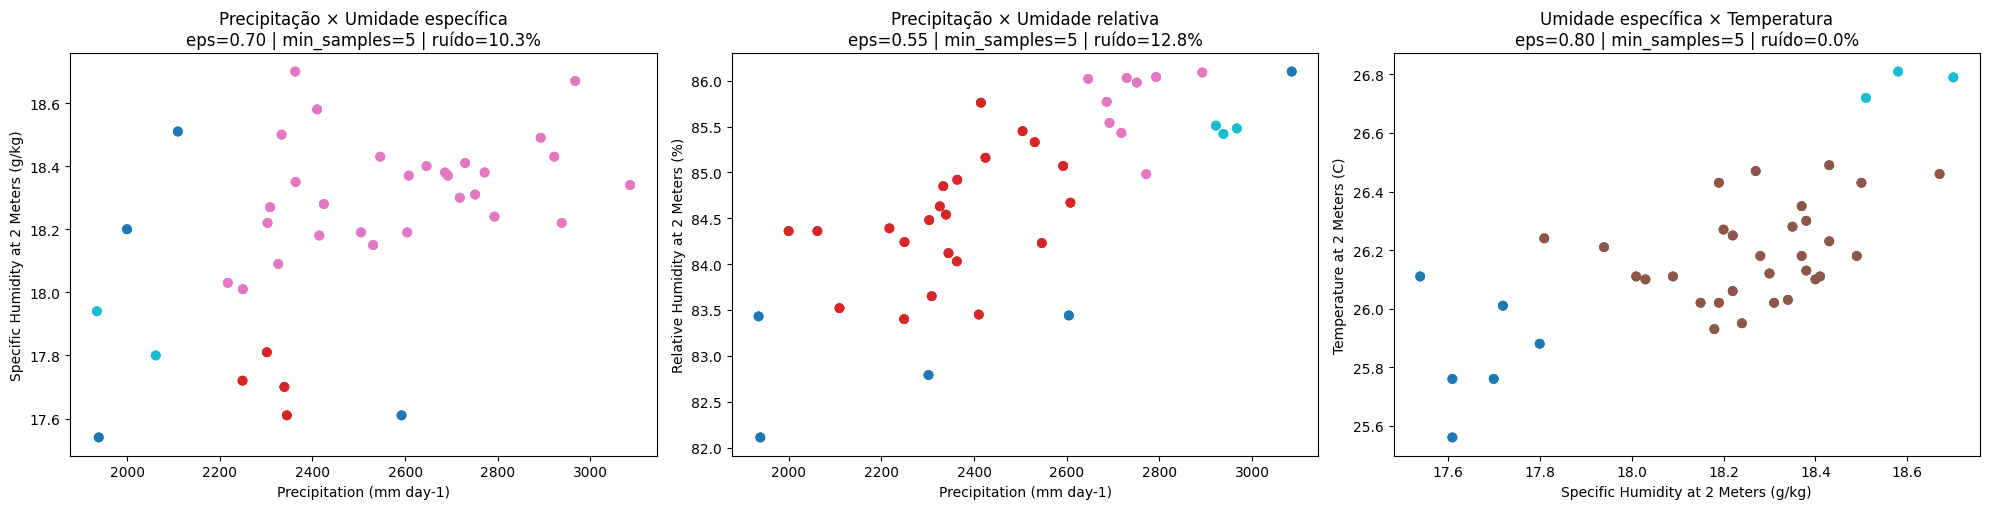

,Par,eps,min_samples,Clusters,Ruído (%),Silhueta
0,Precipitação × Umidade específica,0.7000,5,3,10.2600,0.4785
1,Precipitação × Umidade relativa,0.5500,5,3,12.8200,0.4252
2,Umidade específica × Temperatura,0.8000,5,3,0.0000,0.5057


In [9]:
def selecionar_parametros_dbscan(matriz_padronizada):
    """Seleciona eps e min_samples por um critério explícito e reproduzível."""
    candidatos = []

    for min_samples in [5, 6, 8, 10]:
        for eps in np.round(np.arange(0.20, 1.51, 0.05), 2):
            rotulos = DBSCAN(
                eps=float(eps),
                min_samples=min_samples,
            ).fit_predict(matriz_padronizada)

            mascara_agrupada = rotulos != -1
            quantidade_clusters = len(set(rotulos)) - (1 if -1 in rotulos else 0)
            proporcao_ruido = 1 - mascara_agrupada.mean()

            if (
                2 <= quantidade_clusters <= 4
                and proporcao_ruido <= 0.20
                and mascara_agrupada.sum() > quantidade_clusters
            ):
                silhueta = silhouette_score(
                    matriz_padronizada[mascara_agrupada],
                    rotulos[mascara_agrupada],
                )
                cobertura = mascara_agrupada.mean()
                indice_ajustado = silhueta * cobertura

                candidatos.append(
                    {
                        "eps": float(eps),
                        "min_samples": int(min_samples),
                        "clusters": int(quantidade_clusters),
                        "ruido": float(proporcao_ruido),
                        "silhueta": float(silhueta),
                        "indice_ajustado": float(indice_ajustado),
                        "rotulos": rotulos,
                    }
                )

    if not candidatos:
        raise RuntimeError(
            "Nenhuma configuração DBSCAN atendeu aos critérios definidos."
        )

    # Em empates, prioriza menos ruído e parâmetros menores.
    return min(
        candidatos,
        key=lambda item: (
            -item["indice_ajustado"],
            -item["silhueta"],
            item["ruido"],
            item["clusters"],
            item["eps"],
            item["min_samples"],
        ),
    )


resultados_dbscan = {}
resumo_dbscan = []
fig, eixos = plt.subplots(1, 3, figsize=(20, 5.2))

for eixo, par in zip(eixos, pares_interesse):
    matriz_original = dados[[par["x"], par["y"]]].to_numpy()
    padronizador = StandardScaler()
    matriz_padronizada = padronizador.fit_transform(matriz_original)

    melhor_resultado = selecionar_parametros_dbscan(matriz_padronizada)
    resultados_dbscan[par["nome"]] = melhor_resultado

    resumo_dbscan.append(
        {
            "Par": par["nome"],
            "eps": melhor_resultado["eps"],
            "min_samples": melhor_resultado["min_samples"],
            "Clusters": melhor_resultado["clusters"],
            "Ruído (%)": round(100 * melhor_resultado["ruido"], 2),
            "Silhueta": round(melhor_resultado["silhueta"], 4),
        }
    )

    eixo.scatter(
        dados[par["x"]],
        dados[par["y"]],
        c=melhor_resultado["rotulos"],
        cmap="tab10",
        alpha=0.75,
    )
    eixo.set_title(
        f"{par['nome']}\n"
        f"eps={melhor_resultado['eps']:.2f} | "
        f"min_samples={melhor_resultado['min_samples']} | "
        f"ruído={melhor_resultado['ruido']:.1%}"
    )
    eixo.set_xlabel(par["x"])
    eixo.set_ylabel(par["y"])

plt.tight_layout()
plt.show()
plt.close(fig)

display(pd.DataFrame(resumo_dbscan))

### **Resultado da busca do DBSCAN**

Para esta base e após a padronização, os parâmetros selecionados foram:

- precipitação × umidade específica: `eps = 0,70` e `min_samples = 5`;
- precipitação × umidade relativa: `eps = 0,55` e `min_samples = 5`;
- umidade específica × temperatura: `eps = 0,80` e `min_samples = 5`.

Esses valores não são universais: devem ser recalculados caso a base seja alterada ou receba novas observações.

# **7° — Treinamento e escolha do melhor algoritmo**

1. `Yield` é a variável-alvo e as demais colunas são preditoras.
2. `Crop` é transformada por *one-hot encoding*.
3. A divisão treino/teste é estratificada por cultura.
4. Cada algoritmo é avaliado por validação cruzada de cinco partes.
5. O pré-processamento fica dentro do `Pipeline`, evitando vazamento de dados.
6. O modelo final é escolhido pelo maior R² médio da validação cruzada.
7. No teste são apresentados R², MAE e RMSE.

,Modelo,R² CV,R² teste,MAE,RMSE,Tempo (s),Melhores parâmetros
0,KNN Regressor,0.9879,0.9796,"4,962.0100","9,653.2100",0.5600,"{'escalonador': 'MinMaxScaler', 'modelo__n_nei..."
1,Random Forest Regressor,0.9875,0.9788,"4,711.6400","9,824.2900",5.9200,"{'escalonador': 'passthrough', 'modelo__max_de..."
2,Linear Regression,0.9865,0.9840,"4,988.8900","8,543.6300",0.1200,{'escalonador': 'StandardScaler'}
3,Decision Tree Regressor,0.9827,0.9735,"5,930.1900","11,000.3500",0.5300,"{'escalonador': 'passthrough', 'modelo__max_de..."
4,Support Vector Regressor (SVR),-0.0870,-0.0116,"38,318.8200","67,902.8700",1.1900,"{'escalonador': 'StandardScaler', 'modelo__C':..."


Modelo selecionado pelo R² médio de validação cruzada: KNN Regressor
Melhores parâmetros: {'escalonador': 'MinMaxScaler', 'modelo__n_neighbors': 7, 'modelo__weights': 'distance'}
R² no teste: 0.9796
MAE no teste: 4,962.01
RMSE no teste: 9,653.21


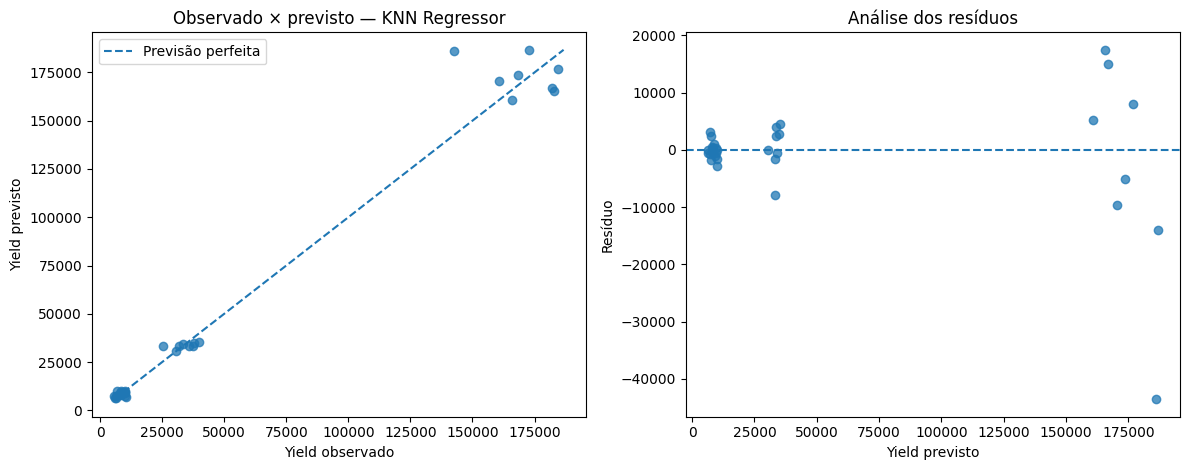

In [10]:
dados_modelagem = pd.get_dummies(
    dados,
    columns=["Crop"],
    prefix="Crop",
    drop_first=True,
    dtype=int,
)

x = dados_modelagem.drop(columns=["Yield"])
y = dados_modelagem["Yield"]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=SEMENTE,
    stratify=dados["Crop"],
)

validacao_cruzada = KFold(
    n_splits=5,
    shuffle=True,
    random_state=SEMENTE,
)

experimentos = [
    {
        "nome": "KNN Regressor",
        "modelo": KNeighborsRegressor(),
        "parametros": {
            "escalonador": [StandardScaler(), MinMaxScaler()],
            "modelo__n_neighbors": [3, 5, 7, 9],
            "modelo__weights": ["uniform", "distance"],
        },
    },
    {
        "nome": "Decision Tree Regressor",
        "modelo": DecisionTreeRegressor(random_state=SEMENTE),
        "parametros": {
            "escalonador": ["passthrough"],
            "modelo__max_depth": [None, 5, 10],
            "modelo__min_samples_split": [2, 5, 10],
            "modelo__min_samples_leaf": [1, 2],
        },
    },
    {
        "nome": "Support Vector Regressor (SVR)",
        "modelo": SVR(),
        "parametros": {
            "escalonador": [StandardScaler(), MinMaxScaler()],
            "modelo__C": [1, 10, 100],
            "modelo__epsilon": [0.01, 0.10, 1.00],
            "modelo__kernel": ["rbf", "linear"],
        },
    },
    {
        "nome": "Random Forest Regressor",
        "modelo": RandomForestRegressor(random_state=SEMENTE, n_jobs=1),
        "parametros": {
            "escalonador": ["passthrough"],
            "modelo__n_estimators": [100],
            "modelo__max_depth": [None, 10],
            "modelo__min_samples_leaf": [1, 2],
            "modelo__max_features": ["sqrt", 1.0],
        },
    },
    {
        "nome": "Linear Regression",
        "modelo": LinearRegression(),
        "parametros": {
            "escalonador": [StandardScaler(), MinMaxScaler(), "passthrough"],
        },
    },
]


def formatar_parametros(parametros):
    parametros_formatados = {}
    for nome, valor in parametros.items():
        if hasattr(valor, "get_params"):
            parametros_formatados[nome] = type(valor).__name__
        else:
            parametros_formatados[nome] = valor
    return parametros_formatados


melhores_modelos = {}
resultados_modelos = []

for experimento in experimentos:
    inicio = perf_counter()
    pipeline = Pipeline(
        [
            ("escalonador", "passthrough"),
            ("modelo", experimento["modelo"]),
        ]
    )

    busca = GridSearchCV(
        estimator=pipeline,
        param_grid=experimento["parametros"],
        scoring="r2",
        cv=validacao_cruzada,
        n_jobs=1,
        error_score="raise",
    )
    busca.fit(x_train, y_train)

    previsoes = busca.best_estimator_.predict(x_test)
    melhores_modelos[experimento["nome"]] = busca
    resultados_modelos.append(
        {
            "Modelo": experimento["nome"],
            "R² CV": float(busca.best_score_),
            "R² teste": float(r2_score(y_test, previsoes)),
            "MAE": float(mean_absolute_error(y_test, previsoes)),
            "RMSE": float(np.sqrt(mean_squared_error(y_test, previsoes))),
            "Tempo (s)": float(perf_counter() - inicio),
            "Melhores parâmetros": str(formatar_parametros(busca.best_params_)),
        }
    )

resumo_modelos = (
    pd.DataFrame(resultados_modelos)
    .sort_values("R² CV", ascending=False)
    .reset_index(drop=True)
)

resumo_exibicao = resumo_modelos.copy()
resumo_exibicao[["R² CV", "R² teste"]] = resumo_exibicao[["R² CV", "R² teste"]].round(4)
resumo_exibicao[["MAE", "RMSE", "Tempo (s)"]] = resumo_exibicao[["MAE", "RMSE", "Tempo (s)"]].round(2)
display(resumo_exibicao)

melhor_nome = resumo_modelos.loc[0, "Modelo"]
modelo_final = melhores_modelos[melhor_nome].best_estimator_
previsoes_modelo_final = modelo_final.predict(x_test)

print(f"Modelo selecionado pelo R² médio de validação cruzada: {melhor_nome}")
print(f"Melhores parâmetros: {formatar_parametros(melhores_modelos[melhor_nome].best_params_)}")
print(f"R² no teste: {r2_score(y_test, previsoes_modelo_final):.4f}")
print(f"MAE no teste: {mean_absolute_error(y_test, previsoes_modelo_final):,.2f}")
print(f"RMSE no teste: {np.sqrt(mean_squared_error(y_test, previsoes_modelo_final)):,.2f}")

limite_minimo = min(y_test.min(), previsoes_modelo_final.min())
limite_maximo = max(y_test.max(), previsoes_modelo_final.max())
residuos = y_test.to_numpy() - previsoes_modelo_final

fig, eixos = plt.subplots(1, 2, figsize=(12, 4.8))
eixos[0].scatter(y_test, previsoes_modelo_final, alpha=0.75)
eixos[0].plot(
    [limite_minimo, limite_maximo],
    [limite_minimo, limite_maximo],
    linestyle="--",
    label="Previsão perfeita",
)
eixos[0].set_title(f"Observado × previsto — {melhor_nome}")
eixos[0].set_xlabel("Yield observado")
eixos[0].set_ylabel("Yield previsto")
eixos[0].legend()

eixos[1].scatter(previsoes_modelo_final, residuos, alpha=0.75)
eixos[1].axhline(0, linestyle="--")
eixos[1].set_title("Análise dos resíduos")
eixos[1].set_xlabel("Yield previsto")
eixos[1].set_ylabel("Resíduo")

plt.tight_layout()
plt.show()
plt.close(fig)

## **7.1 — O uso de PCA garante melhoria na predição?**

Não. PCA reduz a dimensionalidade, mas pode tanto remover ruído quanto descartar informação útil.

Na versão original havia três problemas: o PCA era ajustado sobre `x_test`, `x_test` era transformado duas vezes e `modelo_final` era tratado como se fosse uma função. A correção abaixo ajusta o PCA somente no treino, dentro de um `Pipeline`, e compara as mesmas métricas no mesmo conjunto de teste.

In [11]:
metricas_sem_pca = {
    "Configuração": "Sem PCA",
    "R²": r2_score(y_test, previsoes_modelo_final),
    "MAE": mean_absolute_error(y_test, previsoes_modelo_final),
    "RMSE": np.sqrt(mean_squared_error(y_test, previsoes_modelo_final)),
}

# Mantém o mesmo escalonador e os mesmos hiperparâmetros do modelo vencedor,
# acrescentando apenas o PCA para tornar a comparação mais justa.
escalonador_selecionado = modelo_final.named_steps["escalonador"]
if escalonador_selecionado == "passthrough":
    escalonador_pca = StandardScaler()
else:
    escalonador_pca = clone(escalonador_selecionado)

algoritmo_selecionado = clone(modelo_final.named_steps["modelo"])
modelo_com_pca = Pipeline(
    [
        ("escalonador", escalonador_pca),
        ("pca", PCA(n_components=0.95)),
        ("modelo", algoritmo_selecionado),
    ]
)
modelo_com_pca.fit(x_train, y_train)
previsoes_com_pca = modelo_com_pca.predict(x_test)

metricas_com_pca = {
    "Configuração": "Com PCA (95% da variância)",
    "R²": r2_score(y_test, previsoes_com_pca),
    "MAE": mean_absolute_error(y_test, previsoes_com_pca),
    "RMSE": np.sqrt(mean_squared_error(y_test, previsoes_com_pca)),
}

comparacao_pca = pd.DataFrame([metricas_sem_pca, metricas_com_pca])
comparacao_pca[["R²", "MAE", "RMSE"]] = comparacao_pca[["R²", "MAE", "RMSE"]].round(4)
display(comparacao_pca)

pca_ajustado = modelo_com_pca.named_steps["pca"]
variacao_rmse_percentual = (
    (metricas_sem_pca["RMSE"] - metricas_com_pca["RMSE"])
    / metricas_sem_pca["RMSE"]
    * 100
)

print(f"Variáveis preditoras originais: {x_train.shape[1]}")
print(f"Componentes mantidos: {pca_ajustado.n_components_}")
print(f"Variância acumulada preservada: {pca_ajustado.explained_variance_ratio_.sum():.2%}")
print(f"Variação percentual do RMSE com PCA: {variacao_rmse_percentual:+.4f}%")

if variacao_rmse_percentual > 1:
    print("Nesta divisão, o PCA reduziu o RMSE de forma relevante.")
elif variacao_rmse_percentual > 0:
    print(
        "Nesta divisão, o PCA reduziu o RMSE apenas marginalmente; "
        "isso não demonstra uma melhoria garantida."
    )
elif variacao_rmse_percentual < -1:
    print("Nesta divisão, o PCA aumentou o RMSE de forma relevante.")
else:
    print(
        "Nesta divisão, a diferença de RMSE foi marginal; "
        "não há evidência de melhoria garantida com PCA."
    )

,Configuração,R²,MAE,RMSE
0,Sem PCA,0.9796,"4,962.0056","9,653.2116"
1,Com PCA (95% da variância),0.9796,"4,823.0848","9,644.3535"


Variáveis preditoras originais: 7
Componentes mantidos: 5
Variância acumulada preservada: 97.85%
Variação percentual do RMSE com PCA: +0.0918%
Nesta divisão, o PCA reduziu o RMSE apenas marginalmente; isso não demonstra uma melhoria garantida.


# **8° — Conclusões, pontos fortes e limitações**

## Conclusões

- A base possui 156 observações, quatro culturas e não apresenta valores ausentes ou linhas duplicadas.
- Os três pares de interesse foram efetivamente analisados por K-Means e DBSCAN.
- O DBSCAN foi corrigido com padronização e busca reproduzível de `eps` e `min_samples`.
- Os cinco algoritmos de regressão foram treinados com pipelines e validação cruzada.
- O modelo final foi escolhido pela validação cruzada, preservando o conjunto de teste para avaliação.
- O PCA não garante melhoria; a decisão deve ser baseada nas métricas exibidas.

## Pontos fortes

- código reproduzível com semente fixa;
- pré-processamento dentro dos pipelines;
- comparação por R², MAE e RMSE;
- critérios explícitos para clusterização;
- análise visual de previsões e resíduos.

## Limitações

- a base é pequena e contém apenas quatro culturas;
- resultados estatísticos não provam relações causais;
- potenciais outliers precisam de validação agronômica antes de qualquer remoção;
- parâmetros de clusterização devem ser recalculados quando a base mudar;
- o desempenho deve ser confirmado futuramente com dados de outros períodos e localidades.